In [ ]:
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import gspread
from google.colab import auth
from google.auth import default

# 授权
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

In [ ]:
spreadsheet = gc.open("PageRank Performance")
# 指定sheet名称
worksheet = spreadsheet.worksheet("split-v Summary")

# 获取所有数据（返回的是嵌套list）
data = worksheet.get_all_values()

In [ ]:
graph_name = [data[i][0].replace(" ", "") for i in range(2, 9)]
graph_edges = [int(data[i][1].replace(",", "")) for i in range(2, 9)]
print(graph_name)
print(graph_edges)

['wiki-topcats', 'Twitter', 'soc-liveJournal', 'orkut', 'RMAT', 'ErdosRenyi', 'ForestFire']
[50888414, 2405026092, 85702474, 234370166, 8268666550, 9395215892, 1185662754]


In [ ]:
simTicks = []
nodes = [1, 2, 4, 8, 16, 32, 64, 128, 256]

tmp0 = []
for i in range(2, 9):
    tmp0.append([float(data[i][j]) for j in range(data[1].index('1') , data[1].index('256')+1)])
simTicks.append(tmp0)

tmp0 = []
for i in range(26, 33):
    tmp0.append([float(data[i][j]) for j in range(data[1].index('1') , data[1].index('256')+1)])
simTicks.append(tmp0)

print(simTicks[0])
print(simTicks[1])

[[1471200.0, 807300.0, 473400.0, 308300.0, 186800.0, 129800.0, 108100.0, 91400.0, 94300.0], [94160500.0, 69323800.0, 30761200.0, 17495200.0, 9037100.0, 4856100.0, 2533300.0, 1435500.0, 798800.0], [2617000.0, 1358100.0, 816100.0, 502400.0, 307800.0, 189700.0, 129600.0, 99500.0, 89100.0], [6056800.0, 3105900.0, 1802700.0, 1085700.0, 596900.0, 331800.0, 203400.0, 135600.0, 118000.0], [380634400.0, 428707600.0, 121348000.0, 48271900.0, 23554600.0, 11938200.0, 6628400.0, 3618400.0, 1864300.0], [444833900.0, 221399300.0, 192034100.0, 99941800.0, 50897200.0, 17616800.0, 9080800.0, 2942100.0, 1462200.0], [55077600.0, 27870400.0, 24313300.0, 21502800.0, 5786300.0, 2793600.0, 1362100.0, 706300.0, 360000.0]]
[[2349500.0, 1598800.0, 1246900.0, 843500.0, 594800.0, 446300.0, 373600.0, 349900.0, 348100.0], [184688000.0, 123636500.0, 92752800.0, 57335900.0, 31736600.0, 17193000.0, 9014600.0, 4699100.0, 2620300.0], [7367600.0, 4679600.0, 3676100.0, 2336500.0, 1392600.0, 843800.0, 559500.0, 433700.0, 39

In [ ]:
speedup = []
for i in range(len(simTicks)):
    tmp1 = []
    for j in range(len(simTicks[i])):
        tmp = []
        for k in range(len(simTicks[i][j])):
            tmp.append(simTicks[i][j][0]/simTicks[i][j][k])
        tmp1.append(tmp)
    speedup.append(tmp1)
print(speedup[0])
print(speedup[1])

print(np.average(speedup[0][1:], axis=0))
print(np.average(speedup[1][1:], axis=0))

[[1.0, 1.8223708658491267, 3.1077313054499367, 4.771975348686344, 7.875802997858672, 11.334360554699538, 13.609620721554117, 16.09628008752735, 15.601272534464474], [1.0, 1.3582708968637034, 3.061015174960665, 5.382076226622159, 10.419326996492238, 19.39014847305451, 37.16910748825642, 65.5942180424939, 117.87744116174261], [1.0, 1.92695677785141, 3.2067148633745863, 5.208996815286624, 8.50227420402859, 13.795466526093833, 20.192901234567902, 26.301507537688444, 29.37149270482604], [1.0, 1.950094980520944, 3.3598491152160648, 5.578704982960302, 10.147093315463227, 18.25437010247137, 29.77777777777778, 44.666666666666664, 51.328813559322036], [1.0, 0.8878648290816398, 3.1367175396380658, 7.885216865298445, 16.15966308067214, 31.883734566350036, 57.42477822702311, 105.19411894760115, 204.17014429008208], [1.0, 2.0091928926604554, 2.3164318212234183, 4.450929440934624, 8.739850129280196, 25.250550610780618, 48.98620165624174, 151.1960504401618, 304.2223362057174], [1.0, 1.976204144899248,

In [ ]:
GEPS = []
tmp0 = []
print(data[12:19])
for i in range(12, 19):
    tmp0.append([float(data[i][j]) for j in range(data[1].index('1') , data[1].index('256')+1)])
GEPS.append(tmp0)

tmp0 = []
for i in range(36, 43):
    tmp0.append([float(data[i][j]) for j in range(data[1].index('1') , data[1].index('256')+1)])
GEPS.append(tmp0)

print(GEPS[0])
print(GEPS[1])

new_speedup = (np.array(GEPS[1]).T / np.array(GEPS[1])[:,0].T).T
print(new_speedup)

[['wiki-topcats', '', '69.17946438', '126.0706404', '214.9911872', '330.1226987', '544.843833', '784.1049923', '941.506272', '1113.532035', '1079.287678', '', '', '', '', '', ''], ['Twitter ', '', '51.08354548', '69.38529313', '156.3675079', '274.9355357', '532.2561645', '990.5175314', '1898.729793', '3350.78522', '6021.597626', '117.8774412', '', '', '', '', ''], ['soc-liveJournal', '', '65.49673214', '126.2093719', '210.0293444', '341.1722691', '556.8711761', '903.5579758', '1322.569043', '1722.662794', '1923.736790', '29.3714927', '', '', '', '', ''], ['orkut', '', '77.39075617', '150.9193252', '260.0212637', '431.7401971', '785.2912247', '1412.719506', '2304.524739', '3456.787109', '3972.375695', '51.32881356', '', '', '', '', ''], ['RMAT', '', '43.4467644', '38.57485405', '136.2802279', '342.5871594', '702.0850747', '1385.245104', '2494.92081', '4570.344102', '8870.532157', '204.1701443', '', '', '', '', ''], ['Erdos Renyi', '', '42.24145638', '84.87123394', '97.84945374', '188.01

(np.float64(0.5), np.float64(512.0))


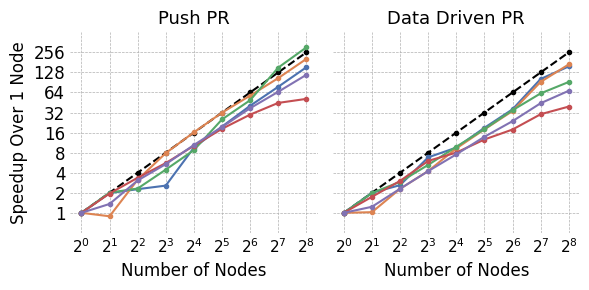

In [ ]:
choose_graph = ['ForestFire','RMAT', 'ErdosRenyi', 'orkut', 'Twitter']
graph_label = ['FF', 'RMAT', 'ER', 'Orkut', 'Twitter']
Algorithm_label = ['Push PR', 'Data Driven PR']
nodes = [1, 2, 4, 8, 16, 32, 64, 128, 256]
linear_speedup = [1, 2, 4, 8, 16, 32, 64, 128, 256]
linear_speedup_name = ['1', '2', '4', '8', '16', '32', '64', '128', '256']

new_speedup = (np.array(GEPS[1]).T / np.array(GEPS[1])[:,0].T).T
# print(new_speedup)

# 颜色方案（Seaborn 深色调色盘）
colors = sns.color_palette("deep", len(choose_graph))

fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=True)
for i,ax in enumerate(axes):
    ax.set_ylim(0.5, 512)
    ax.set_xscale('log', base=2)
    ax.set_yscale('log', base=2)
    ax.set_xticks(nodes)
    ax.set_yticks([1, 2, 4, 8, 16, 32, 64, 128, 256])
    ax.set_yticklabels([1, 2, 4, 8, 16, 32, 64, 128, 256], fontsize=12)
    ax.set_xlabel(f'Number of Nodes', fontsize=12)
    ax.set_title(f"{Algorithm_label[i]}", fontsize=13)
    ax.grid(True, linestyle="--", linewidth=0.5)
    ax.spines[:].set_visible(False)
    ax.set_xticklabels([r"$2^{" + f"{round(np.log2(node))}" + r"}$" for node in nodes], fontsize=11)
    ax.tick_params(length=0)
    if i == 0:
        ax.set_ylabel('Speedup Over 1 Node', fontsize=12)
        # ax.set_yticks(nodes)
        # ax.set_yticklabels(linear_speedup_name)
        print(ax.get_ylim())
        ax.plot(nodes, linear_speedup, marker=".", label="Linear", linestyle="--", color="black")
        for graph_idx in range(len(choose_graph)):
            ax.plot(nodes, speedup[i][graph_name.index(choose_graph[graph_idx])], marker=".", label=graph_label[graph_idx], linestyle="-", color=colors[graph_idx])
    else:
        ax.plot(nodes, linear_speedup, marker=".", linestyle="--", color="black")
        for graph_idx in range(len(choose_graph)):
            ax.plot(nodes, new_speedup[graph_name.index(choose_graph[graph_idx])], marker=".", linestyle="-", color=colors[graph_idx])

# fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=len(choose_graph)+1, columnspacing=.5)
# fig.suptitle("Different PageRank Speedup over one machine on different nodes", y=1.03)
# 调整布局
plt.tight_layout()  # 给legend和总标题留出空间)
plt.savefig("PR_speedupv4.pdf", format="pdf", bbox_inches="tight")
plt.show()

(np.float64(0.5), np.float64(512.0))


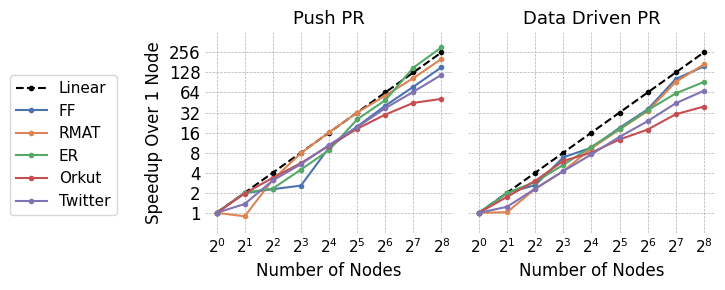

In [ ]:
choose_graph = ['ForestFire','RMAT', 'ErdosRenyi', 'orkut', 'Twitter']
graph_label = ['FF', 'RMAT', 'ER', 'Orkut', 'Twitter']
Algorithm_label = ['Push PR', 'Data Driven PR']
nodes = [1, 2, 4, 8, 16, 32, 64, 128, 256]
linear_speedup = [1, 2, 4, 8, 16, 32, 64, 128, 256]
linear_speedup_name = ['1', '2', '4', '8', '16', '32', '64', '128', '256']

new_speedup = (np.array(GEPS[1]).T / np.array(GEPS[1])[:,0].T).T
# print(new_speedup)

# 颜色方案（Seaborn 深色调色盘）
colors = sns.color_palette("deep", len(choose_graph))

fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=True)
for i,ax in enumerate(axes):
    ax.set_ylim(0.5, 512)
    ax.set_xscale('log', base=2)
    ax.set_yscale('log', base=2)
    ax.set_xticks(nodes)
    ax.set_yticks([1, 2, 4, 8, 16, 32, 64, 128, 256])
    ax.set_yticklabels([1, 2, 4, 8, 16, 32, 64, 128, 256], fontsize=12)
    ax.set_xlabel(f'Number of Nodes', fontsize=12)
    ax.set_title(f"{Algorithm_label[i]}", fontsize=13)
    ax.grid(True, linestyle="--", linewidth=0.5)
    ax.spines[:].set_visible(False)
    ax.set_xticklabels([r"$2^{" + f"{round(np.log2(node))}" + r"}$" for node in nodes], fontsize=11)
    ax.tick_params(length=0)

    if i == 0:
        ax.set_ylabel('Speedup Over 1 Node', fontsize=12)
        # ax.set_yticks(nodes)
        # ax.set_yticklabels(linear_speedup_name)
        print(ax.get_ylim())
        ax.plot(nodes, linear_speedup, marker=".", label="Linear", linestyle="--", color="black")
        for graph_idx in range(len(choose_graph)):
            ax.plot(nodes, speedup[i][graph_name.index(choose_graph[graph_idx])], marker=".", label=graph_label[graph_idx], linestyle="-", color=colors[graph_idx])
    else:
        ax.plot(nodes, linear_speedup, marker=".", linestyle="--", color="black")
        for graph_idx in range(len(choose_graph)):
            ax.plot(nodes, new_speedup[graph_name.index(choose_graph[graph_idx])], marker=".", linestyle="-", color=colors[graph_idx])

fig.legend(
    loc='center right',           # 图例锚点在 legend 框右边中间
    bbox_to_anchor=(-0.01, 0.5),  # 放在整张图外部的左边（x < 0）
    ncol=1,                       # 竖排
    fontsize=11,
    columnspacing=0.5
)

# fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=len(choose_graph)+1, columnspacing=.5)
# fig.suptitle("Different PageRank Speedup over one machine on different nodes", y=1.03)
# 调整布局
plt.tight_layout()  # 给legend和总标题留出空间)
plt.savefig("PR_speedupv4_legended.pdf", format="pdf", bbox_inches="tight")
plt.show()

FF
[32, 64, 128, 256]
[180.0725, 359.38832, 469.010203, 1224.960026, 1715.505596]
RMAT
[32, 64, 128, 256]
[277.225007, 283.448594, 635.502118, 1174.112279, 2571.481483]
ER
[32, 64, 128, 256]
[716.281555, 1421.815474, 2088.382192, 3753.505579, 7028.40164]
(np.float64(16.0), np.float64(65536.0))


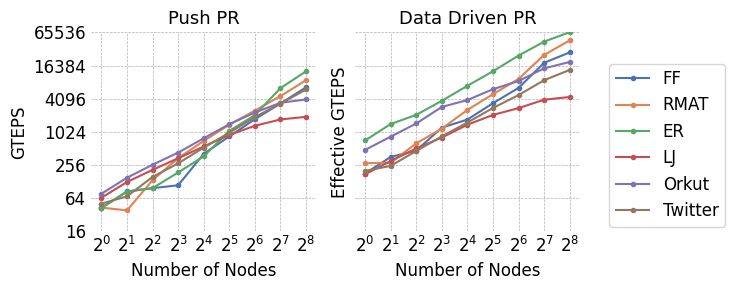

In [ ]:
choose_graph = ['ForestFire','RMAT', 'ErdosRenyi', 'soc-liveJournal', 'orkut', 'Twitter']
graph_label = ['FF', 'RMAT', 'ER', 'LJ', 'Orkut', 'Twitter']
Algorithm_label = ['Push PR', 'Data Driven PR']
nodes = [1, 2, 4, 8, 16, 32, 64, 128, 256]
y_label = [16, 64, 256, 1024, 4096, 16384, 65536]
y_label_name = ['16', '64', '256', '1024', '4096', '16384', '65536']

# 颜色方案（Seaborn 深色调色盘）
colors = sns.color_palette("deep", len(choose_graph))

fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=True)
for i,ax in enumerate(axes):
    ax.set_ylim(16, 65536)
    ax.set_xscale('log', base=2)
    ax.set_yscale('log', base=2)
    ax.set_xticks(nodes)
    ax.set_yticks(y_label)
    ax.set_yticklabels(y_label_name, fontsize=12)
    ax.set_xlabel(f'Number of Nodes', fontsize=12)
    ax.set_title(f"{Algorithm_label[i]}", fontsize=13)
    ax.grid(True, linestyle="--", linewidth=0.5)
    ax.spines[:].set_visible(False)
    ax.set_xticklabels([r"$2^{" + f"{round(np.log2(node))}" + r"}$" for node in nodes], fontsize=12)
    ax.tick_params(length=0)

    if i == 0:
        ax.set_ylabel('GTEPS', fontsize=12)
        for graph_idx in range(len(choose_graph)):
            ax.plot(nodes, GEPS[i][graph_name.index(choose_graph[graph_idx])], marker=".", label=graph_label[graph_idx], linestyle="-", color=colors[graph_idx])
    else:
        ax.set_ylabel('Effective GTEPS', fontsize=12)
        # ax.plot(nodes, linear_speedup, marker=".", linestyle="-", color="black")
        for graph_idx in range(len(choose_graph)):
            ax.plot(nodes, GEPS[i][graph_name.index(choose_graph[graph_idx])], marker=".", linestyle="-", color=colors[graph_idx])

            if graph_label[graph_idx] in ["ER","RMAT","FF"]:
                print(graph_label[graph_idx])
                print(nodes[5:])
                print(GEPS[i][graph_name.index(choose_graph[graph_idx])][:5])
print(ax.get_ylim())

fig.legend(
    loc='center left',           # 图例锚点在 legend 框左边中间
    bbox_to_anchor=(1.01, 0.5),  # 放在图的外部右边（x > 1）
    ncol=1,                      # 一列竖排
    fontsize=12
)

# fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=len(choose_graph)+1, columnspacing=.5)
# fig.suptitle("Different PageRank Performance over one machine on different nodes", y=1.03)
# 调整布局
plt.tight_layout()  # 给legend和总标题留出空间)
plt.savefig("PR_GEPSv4_legended.pdf", format="pdf", bbox_inches="tight")
plt.show()

(np.float64(16.0), np.float64(65536.0))


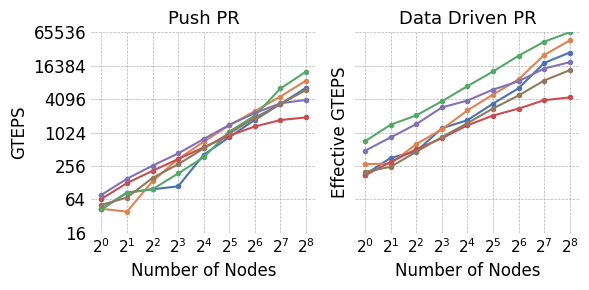

In [ ]:
choose_graph = ['ForestFire','RMAT', 'ErdosRenyi', 'soc-liveJournal', 'orkut', 'Twitter']
graph_label = ['FF', 'RMAT', 'ER', 'LJ', 'Orkut', 'Twitter']
Algorithm_label = ['Push PR', 'Data Driven PR']
nodes = [1, 2, 4, 8, 16, 32, 64, 128, 256]
y_label = [16, 64, 256, 1024, 4096, 16384, 65536]
y_label_name = ['16', '64', '256', '1024', '4096', '16384', '65536']

# 颜色方案（Seaborn 深色调色盘）
colors = sns.color_palette("deep", len(choose_graph))

fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=True)
for i,ax in enumerate(axes):
    ax.set_ylim(16, 65536)
    ax.set_xscale('log', base=2)
    ax.set_yscale('log', base=2)
    ax.set_xticks(nodes)
    ax.set_yticks(y_label)
    ax.set_yticklabels(y_label_name, fontsize=12)
    ax.set_xlabel(f'Number of Nodes', fontsize=12)
    ax.set_title(f"{Algorithm_label[i]}", fontsize=13)
    ax.grid(True, linestyle="--", linewidth=0.5)
    ax.spines[:].set_visible(False)
    ax.set_xticklabels([r"$2^{" + f"{round(np.log2(node))}" + r"}$" for node in nodes], fontsize=11)
    ax.tick_params(length=0)
    if i == 0:
        ax.set_ylabel('GTEPS', fontsize=12)
        for graph_idx in range(len(choose_graph)):
            ax.plot(nodes, GEPS[i][graph_name.index(choose_graph[graph_idx])], marker=".", label=graph_label[graph_idx], linestyle="-", color=colors[graph_idx])
    else:
        ax.set_ylabel('Effective GTEPS', fontsize=12)
        # ax.plot(nodes, linear_speedup, marker=".", linestyle="-", color="black")
        for graph_idx in range(len(choose_graph)):
            ax.plot(nodes, GEPS[i][graph_name.index(choose_graph[graph_idx])], marker=".", linestyle="-", color=colors[graph_idx])
print(ax.get_ylim())
# fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=len(choose_graph)+1, columnspacing=.5)
# fig.suptitle("Different PageRank Performance over one machine on different nodes", y=1.03)
# 调整布局
plt.tight_layout()  # 给legend和总标题留出空间)
plt.savefig("PR_GEPSv4.pdf", format="pdf", bbox_inches="tight")
plt.show()